In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve


V min/max: 0.0 1.0
Mean electric field: -1.0
Mean current density: -0.5


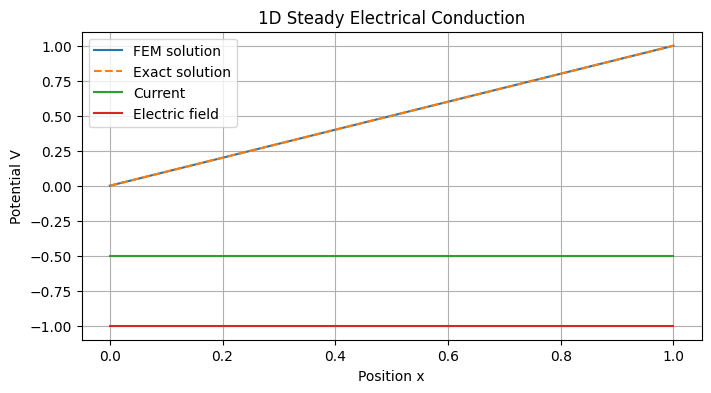

In [88]:

def FEM_element_based(sigma_values, L, Nx):
    h = L / (Nx - 1)

    K_global = np.zeros((Nx, Nx))

    for e in range(Nx - 1):
        sigma = sigma_values[e]
        K_e = (sigma / h) * np.array([[1, -1], [-1, 1]])
        K_global[e:e+2, e:e+2] += K_e

    return K_global, h


def BC_Solver(K_Full, L_BC, R_BC):
    # Potential
    V = np.zeros(Nx)
    V[0] =  L_BC
    V[-1] = R_BC

    # Reduced matrix
    K = csr_matrix(K_Full[1:-1, 1:-1])

    # RHS: no source in the PDE, but boundary values contribute
    b = np.zeros(Nx - 2)
    b[0]  -= K_Full[1,0]   * V[0]
    b[-1] -= K_Full[-2,-1] * V[-1]

    # Solve
    V_interior = spsolve(K, b)
    V[1:-1] = V_interior
    return V


# Parameters
L = 1.0
Nx = 50
x = np.linspace(0, L, Nx)

sigma_values = 0.5 * np.ones(Nx) # The conductivity parameter

# Assemble full matrix
K_full, h = FEM_element_based(sigma_values, L, Nx)

# Incorporate BC, and solve
V = BC_Solver(K_full, 0.0, 1.0)

# Derived quantities
E = -np.gradient(V, x)
J = sigma_values * E

print("V min/max:", V.min(), V.max())
print("Mean electric field:", np.mean(E))
print("Mean current density:", np.mean(J))

# Exact solution
V_exact = x / L

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x, V, label='FEM solution')
plt.plot(x, V_exact, '--', label='Exact solution')
plt.plot(x, J, label='Current')
plt.plot(x, E, label='Electric field')
plt.xlabel('Position x')
plt.ylabel('Potential V')
plt.title('1D Steady Electrical Conduction')
plt.grid(True)
plt.legend()
#plt.savefig("./FEM/P1d.png", dpi=200)
plt.show()

The next goal is to make $\sigma$ dynamic, but we start with a simple artificial process of making it variable of some constant, let $x$

$$=> \sigma(x) = x^2$$

**Remark**: The properties should be assigned to elements, because nodes are the soutions, so:
$$x_i = \frac {x_{i-1} + x_{i+1}}{2}$$

In [89]:
# First we define a function
def sigma_x(x):
    return 1 + x**2

# Now we fill up the sigma 

x_node = np.linspace(0, L, Nx)
x_elem = 0.5 * x_node[:-1] + x_node[1:]

sigma_vals = sigma_x(x_elem)

# Assemble full matrix
K_full, h = FEM_element_based(sigma_vals, L, Nx)


# Incorporate BC, and solve
V = BC_Solver(K_full, 0.0, 1.0)


# Derived quantities
# element wise electric field
E = -(V[1:] - V[:-1])/h
#E = -np.gradient(V, x)
J = sigma_vals * E


print("V min/max:", V.min(), V.max())
print("Mean electric field:", np.mean(E))
print("Mean current density:", np.mean(J))


# Exact solution
V_exact = x / L



V min/max: 0.0 1.0
Mean electric field: -1.0000000000000002
Mean current density: -1.5317555586831506


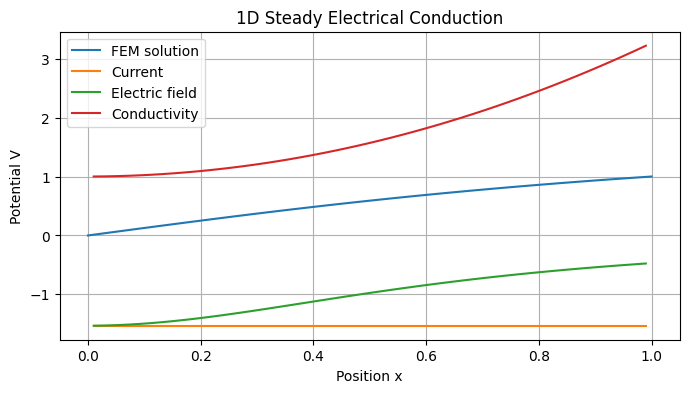

In [92]:
# Plot
plt.figure(figsize=(8, 4))
plt.plot(x_node, V, label='FEM solution')
#plt.plot(x, V_exact, '--', label='Exact solution')
plt.plot(x_elem, J, label='Current')
plt.plot(x_elem, E, label='Electric field')
plt.plot(x_elem,sigma_vals, label='Conductivity')
plt.xlabel('Position x')
plt.ylabel('Potential V')
plt.title('1D Steady Electrical Conduction')
plt.grid(True)
plt.legend()
#plt.savefig("./FEM/P1d.png", dpi=200)
plt.show()

In [93]:
print("J variation:", J.max() - J.min())

J variation: 9.725553695716371e-14


# 1D Electrical Conduction with Variable Conductivity

## Problem Setup

We consider steady-state 1D electrical conduction with spatially varying conductivity:

$$
\frac{d}{dx} \left( \sigma(x)\frac{dV}{dx} \right) = 0
$$

with Dirichlet boundary conditions:

$$
V(0)=0, \quad V(L)=1
$$

Instead of a constant material property, we define:

$$
\sigma(x) = 1 + x^2
$$

---

## Numerical Approach

The problem is solved using the **Finite Element Method (FEM)** with:

- Linear 1D elements  
- Element-wise conductivity $\sigma_e$  
- Sparse linear system solution  

---

## Results

### Potential $V(x)$

- The solution is **nonlinear** (curved profile)

**Interpretation:**  
Regions with low conductivity require a **higher potential gradient**, while high conductivity regions require less.

---

### Electric Field $E(x)$

$$
E(x) = -\frac{dV}{dx}
$$

- Non-uniform and decreases in magnitude as $x$ increases  

**Interpretation:**  
As $\sigma(x)$ increases, the system reduces the electric field:

$$
E(x) \sim \frac{1}{\sigma(x)}
$$

---

### Current Density $J(x)$

$$
J(x) = \sigma(x) E(x)
$$

Observed:

J variation ≈ $10^{-13}$
**Interpretation:**  
The current is **constant across the domain**, confirming:

$$
\frac{dJ}{dx} = 0
$$

This is the key physical validation of the simulation.

---

## Numerical Validation
V min/max: 0.0 / 1.0
Mean electric field: -1.0
Mean current density: -1.53
J variation: ~1e-13

- Boundary conditions satisfied  
- Average electric field consistent with $E_{\text{avg}} = -1/L$  
- Current conservation holds  

---

## Key Insight

The system self-adjusts to maintain constant current:

$$
\sigma(x) \uparrow \quad \Rightarrow \quad E(x) \downarrow
$$

This redistribution is fundamental in transport physics.

---

## Relevance

- Demonstrates **non-uniform material modeling** using FEM  
- Validates **conservation laws numerically**  
- Forms a base for:
  - strain-dependent conductivity $\sigma(\varepsilon)$  
  - nonlinear multiphysics coupling  
  - hybrid physics + ML surrogate models  

---

## Conclusion

This implementation successfully extends a simple conduction model into a **physically meaningful, variable-property system**, capturing nontrivial behavior while preserving core physical laws.

---

## Next Step

Replace artificial conductivity with physics-driven relation:

$$
\sigma = \sigma(\varepsilon(x))
$$

This enables coupling between **mechanics and transport**, aligning the model with real semiconductor behavior.